**Датасет:** Wine Quality Dataset  
**Ссылка:** https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

## 1. Импорт библиотек и настройка

In [16]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

RANDOM_SEED = 42

## 2. Загрузка данных

In [17]:
file_path = "/content/WineQT.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head())

Shape: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 3. Первичный анализ данных

Проверим:
- размер датасета;
- типы признаков;
- пропуски;
- дубликаты;
- распределение классов.

In [18]:
print("Info:")
df.info()

print("\nDescribe:")
display(df.describe())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicates:", df.duplicated().sum())

print("\nClass distribution:")
display(df["quality"].value_counts().sort_index())

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB

Describe:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000



Data types:


,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64



Missing values:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0



Duplicates: 0

Class distribution:


,count
quality,
3,6
4,33
5,483
6,462
7,143
8,16


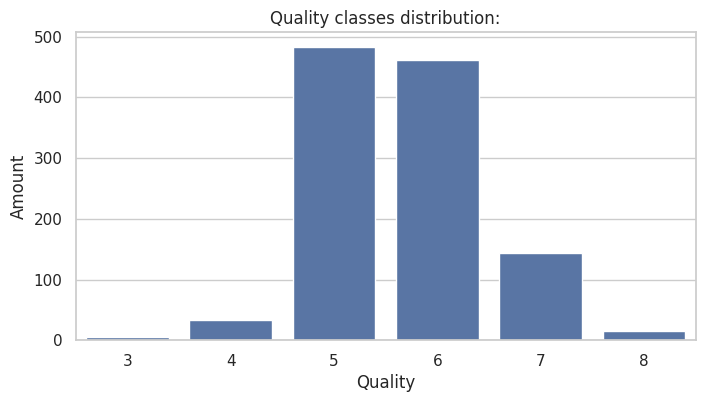

In [19]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="quality")
plt.title("Quality classes distribution:")
plt.xlabel("Quality")
plt.ylabel("Amount")
plt.show()

## 4. Подготовка данных

In [20]:
df_model = df.copy()

if "Id" in df_model.columns:
    df_model = df_model.drop(columns=["Id"])

X = df_model.drop(columns=["quality"])
y = df_model["quality"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", sorted(y.unique()))

X shape: (1143, 11)
y shape: (1143,)
Classes: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (914, 11)
Test shape: (229, 11)


## 5. Почему масштабирование важно для KNN

KNN основан на расстояниях между объектами.  
Если один признак измеряется в маленьком диапазоне, а другой — в большом, то признак с большим масштабом начнёт доминировать в расстоянии.

Без масштабирования KNN будет слишком сильно ориентироваться на признаки с крупными числовыми значениями.

## 6. Базовый KNN без масштабирования

In [22]:
knn_no_scale = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("knn", KNeighborsClassifier())
])

knn_no_scale.fit(X_train, y_train)
y_pred_no_scale = knn_no_scale.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_no_scale))
print("Precision (weighted):", precision_score(y_test, y_pred_no_scale, average="weighted", zero_division=0))
print("Recall (weighted):", recall_score(y_test, y_pred_no_scale, average="weighted", zero_division=0))
print("F1 (weighted):", f1_score(y_test, y_pred_no_scale, average="weighted", zero_division=0))

Accuracy: 0.4890829694323144
Precision (weighted): 0.46533163298166963
Recall (weighted): 0.4890829694323144
F1 (weighted): 0.47096022609123045


## 7. KNN после масштабирования

In [23]:
knn_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

knn_scaled.fit(X_train, y_train)
y_pred_scaled = knn_scaled.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("Precision (weighted):", precision_score(y_test, y_pred_scaled, average="weighted", zero_division=0))
print("Recall (weighted):", recall_score(y_test, y_pred_scaled, average="weighted", zero_division=0))
print("F1 (weighted):", f1_score(y_test, y_pred_scaled, average="weighted", zero_division=0))

Accuracy: 0.5764192139737991
Precision (weighted): 0.553218807503227
Recall (weighted): 0.5764192139737991
F1 (weighted): 0.5632480360996469


In [24]:
comparison_scaling = pd.DataFrame({
    "model": ["KNN without scaling", "KNN with StandardScaler"],
    "accuracy": [
        accuracy_score(y_test, y_pred_no_scale),
        accuracy_score(y_test, y_pred_scaled)
    ],
    "precision_weighted": [
        precision_score(y_test, y_pred_no_scale, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_scaled, average="weighted", zero_division=0)
    ],
    "recall_weighted": [
        recall_score(y_test, y_pred_no_scale, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_scaled, average="weighted", zero_division=0)
    ],
    "f1_weighted": [
        f1_score(y_test, y_pred_no_scale, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_scaled, average="weighted", zero_division=0)
    ]
})

display(comparison_scaling)

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,KNN without scaling,0.489083,0.465332,0.489083,0.470960
1,KNN with StandardScaler,0.576419,0.553219,0.576419,0.563248


### Вывод по масштабированию

Обычно качество KNN **заметно улучшается после масштабирования**, потому что модель начинает учитывать все признаки более сбалансированно.

Поэтому для KNN масштабирование имеет большое значение и меняет результат.

## 8. Влияние числа соседей `k`

In [25]:
k_values = list(range(1, 31))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

k_scores = []

for k in k_values:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    k_scores.append(scores.mean())

k_results = pd.DataFrame({
    "k": k_values,
    "cv_accuracy": k_scores
})

display(k_results.head())
display(k_results.sort_values("cv_accuracy", ascending=False).head(10))

,k,cv_accuracy
0,1,0.560181
1,2,0.533940
2,3,0.504384
3,4,0.535009
4,5,0.537176


,k,cv_accuracy
26,27,0.574461
24,25,0.567880
20,21,0.567862
25,26,0.566799
27,28,0.563508
21,22,0.563502
19,20,0.562373
17,18,0.561256
15,16,0.561238
14,15,0.560187


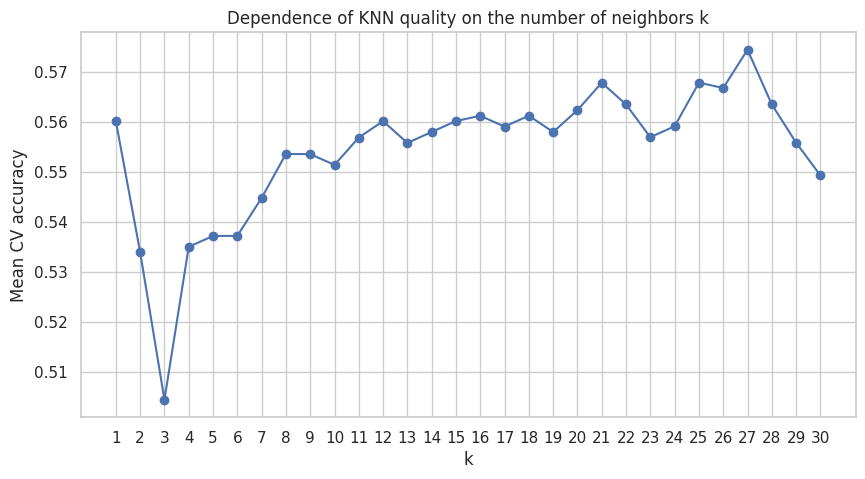

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(k_results["k"], k_results["cv_accuracy"], marker="o")
plt.title("Dependence of KNN quality on the number of neighbors k")
plt.xlabel("k")
plt.ylabel("Mean CV accuracy")
plt.xticks(k_values)
plt.show()

## 9. Исследование разных вариантов весов и метрик расстояния

Проверим:
- `weights`: `uniform`, `distance`
- `metric`: `euclidean`, `manhattan`, `minkowski`

In [27]:
experiments = []

for weights in ["uniform", "distance"]:
    for metric in ["euclidean", "manhattan", "minkowski"]:
        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(
                n_neighbors=5,
                weights=weights,
                metric=metric,
                p = 3 if metric == "minkowski" else 2,
            ))
        ])

        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")

        experiments.append({
            "weights": weights,
            "metric": metric,
            "cv_accuracy_mean": scores.mean(),
            "cv_accuracy_std": scores.std()
        })

experiments_df = pd.DataFrame(experiments).sort_values("cv_accuracy_mean", ascending=False)
display(experiments_df)

,weights,metric,cv_accuracy_mean,cv_accuracy_std
4,distance,manhattan,0.594067,0.040467
5,distance,minkowski,0.592980,0.052501
3,distance,euclidean,0.590788,0.039533
0,uniform,euclidean,0.537176,0.037912
2,uniform,minkowski,0.534985,0.060757
1,uniform,manhattan,0.534967,0.030842


- Разные метрики расстояния по-разному измеряют «близость» объектов.
- `euclidean` — обычное евклидово расстояние.
- `manhattan` — сумма модулей разностей по координатам.
- `minkowski` — более общий вариант, который включает некоторые другие метрики как частные случаи.
- `weights='distance'` иногда помогает, потому что более близкие соседи начинают влиять сильнее.

## 10. Подбор гиперпараметров через GridSearchCV

Выполним подбор гиперпараметров на **train**-части данных.

In [28]:
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": list(range(1, 31)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan", "minkowski"]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 26, 'knn__weights': 'distance'}
Best CV score: 0.6521167357232931


In [29]:
best_knn = grid.best_estimator_
y_pred_best = best_knn.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred_best))
print("Test precision (weighted):", precision_score(y_test, y_pred_best, average="weighted", zero_division=0))
print("Test recall (weighted):", recall_score(y_test, y_pred_best, average="weighted", zero_division=0))
print("Test F1 (weighted):", f1_score(y_test, y_pred_best, average="weighted", zero_division=0))

print("\nClassification report:")
print(classification_report(y_test, y_pred_best, zero_division=0))

Test accuracy: 0.6899563318777293
Test precision (weighted): 0.6571489536144298
Test recall (weighted): 0.6899563318777293
Test F1 (weighted): 0.6694994276102585

Classification report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.71      0.79      0.75        97
           6       0.66      0.73      0.69        92
           7       0.70      0.48      0.57        29
           8       0.00      0.00      0.00         3

    accuracy                           0.69       229
   macro avg       0.35      0.33      0.34       229
weighted avg       0.66      0.69      0.67       229



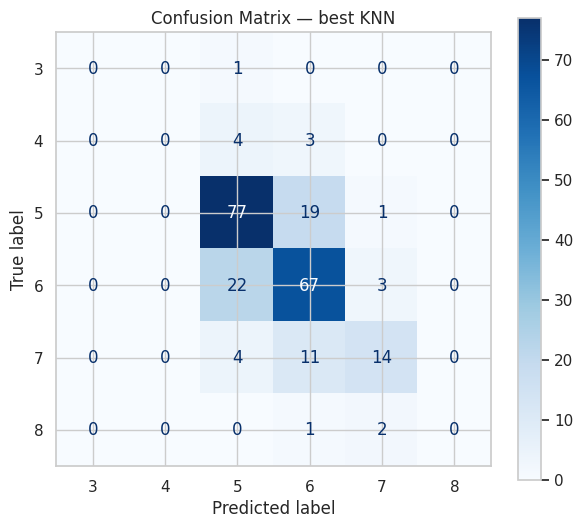

In [30]:
cm = confusion_matrix(y_test, y_pred_best, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix — best KNN")
plt.show()

## 11. Итоговые выводы

### Что удалось выяснить
1. **KNN хорошо подходит** для этого датасета (_Wine Quality_), потому что признаки в основном числовые и расстояния между объектами осмысленны.
2. **Масштабирование критически важно**: без него KNN обычно работает хуже.
3. Качество модели заметно зависит от:
   - числа соседей `n_neighbors`;
   - схемы весов (`uniform` / `distance`);
   - метрики расстояния.
4. Подбор гиперпараметров через **кросс-валидацию** помогает найти более удачную конфигурацию модели.
5. Тестовую выборку нельзя использовать для настройки параметров, потому что она нужна только для финальной независимой оценки.

### Ограничения KNN
- KNN может быть чувствителен к шуму и выбросам.
- KNN не строит явную интерпретируемую формулу, как, например, линейная модель.
- На больших датасетах KNN может работать медленнее при предсказании, потому что ему нужно сравнивать объект со многими точками обучающей выборки.